Import Libraries

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


Load and Split Data

In [47]:
df = pd.read_csv("../data/data_cleaned.csv").dropna()
df.head()

,clean_tweet,class
0,!!! rt as a woman you shouldnt complain about ...,2
1,!!!!! rt boy dats cold...tyga dwn bad for cuff...,1
2,!!!!!!! rt dawg!!!! rt you ever fuck a bitch a...,1
3,!!!!!!!!! rt she look like a tranny,1
4,!!!!!!!!!!!!! rt the shit you hear about me mi...,1


In [74]:
X = df["clean_tweet"]
y = df["class"]
# split Train set (80%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X , y, test_size=0.20, random_state=42, stratify= y
)

# split validation and test set (10% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# save the splits
train_df = pd.concat([X_train, y_train], axis=1)
val_df = pd.concat([X_val, y_val], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)
train_df.to_csv('../data/train.csv', index=False)
val_df.to_csv('../data/val.csv', index=False)
test_df.to_csv('../data/test.csv', index=False)

Create Pipeline

In [49]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
    ("clf", LogisticRegression(class_weight='balanced', max_iter=1000))
])

Train Model

In [50]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


Prediction

In [51]:
y_pred = pipeline.predict(X_test)

Evaluation Metrics

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.33      0.58      0.42       143
           1       0.97      0.87      0.92      1919
           2       0.78      0.94      0.85       417

    accuracy                           0.87      2479
   macro avg       0.69      0.80      0.73      2479
weighted avg       0.90      0.87      0.88      2479



Confusion Matrix

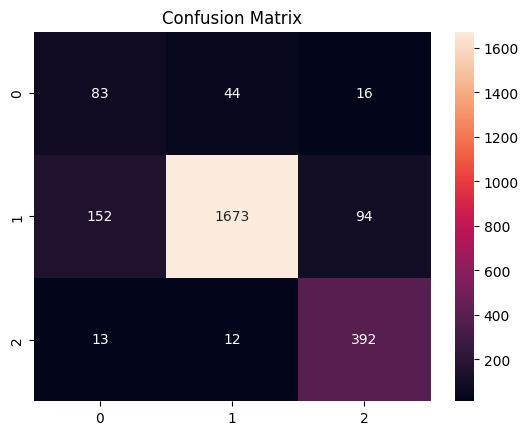

In [64]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

Fine Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# Define the parameters to test
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)], # Test n-grams
    'tfidf__max_features': [2500, 5000, 7500, 10000],
    'clf__C': [0.1, 1, 5, 10],  # Regularization strength
}

# Use Macro F1 to treat each class equal
macro_f1_scorer = make_scorer(f1_score, average='macro')

In [63]:
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    scoring=macro_f1_scorer, 
    cv=5, 
    verbose=1, 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Macro F1: {grid_search.best_score_:.3f}")

# save the best pipeline
best_pipeline = grid_search.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'clf__C': 1, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 3)}
Best Macro F1: 0.723


Best Baseline Evaluations 

In [75]:
y_pred_best = best_pipeline.predict(X_test)

print("Classification Report (Baseline):")
print(classification_report(y_test, y_pred_best))

Classification Report (Baseline):
              precision    recall  f1-score   support

           0       0.34      0.59      0.43       143
           1       0.97      0.87      0.92      1919
           2       0.78      0.94      0.85       417

    accuracy                           0.87      2479
   macro avg       0.70      0.80      0.73      2479
weighted avg       0.90      0.87      0.88      2479



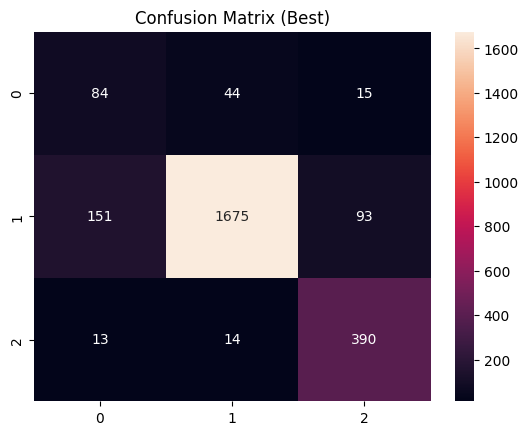

In [69]:
cm_best = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm_best, annot=True, fmt='d')
plt.title("Confusion Matrix (Best)")
plt.show()

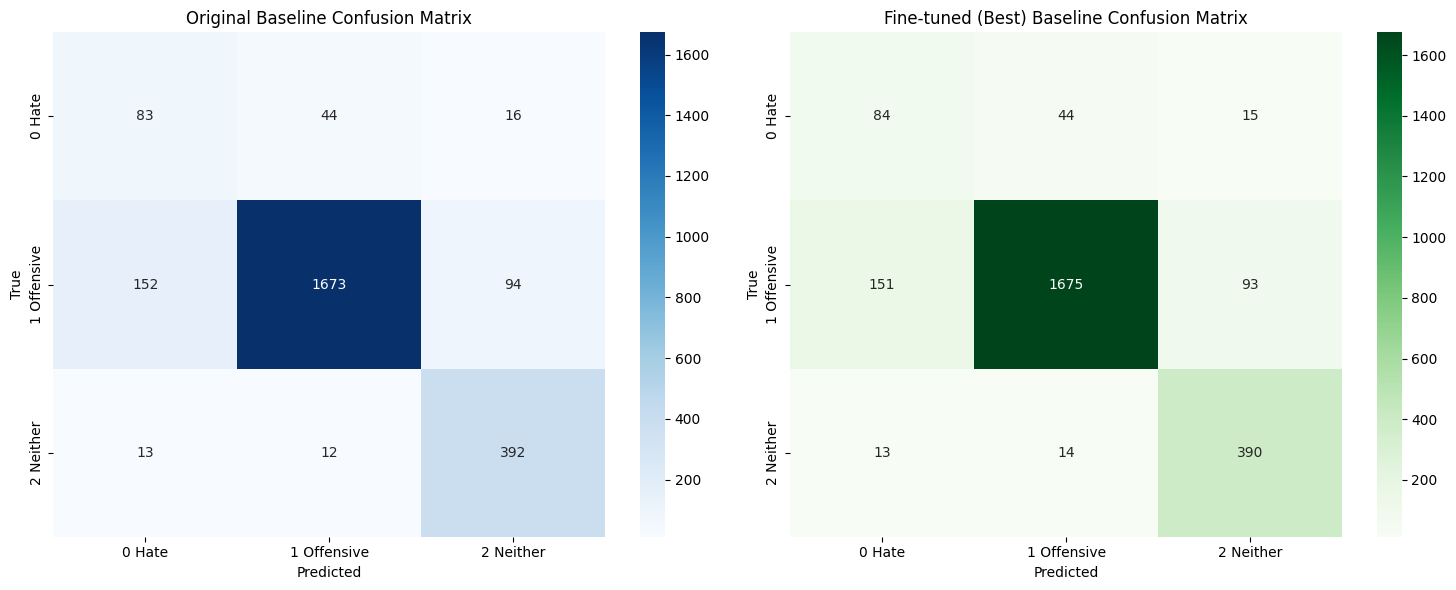

In [76]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['0 Hate', '1 Offensive', '2 Neither'],
            yticklabels=['0 Hate', '1 Offensive', '2 Neither'])
ax[0].set_title("Original Baseline Confusion Matrix")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("True")
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', ax=ax[1],
            xticklabels=['0 Hate', '1 Offensive', '2 Neither'],
            yticklabels=['0 Hate', '1 Offensive', '2 Neither'])
ax[1].set_title("Fine-tuned (Best) Baseline Confusion Matrix")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("True")
plt.tight_layout()
plt.savefig('../src/confusion_matrices_baseline.png', dpi=300, bbox_inches='tight')
plt.show()